## Natural Language Processing with Disaster Tweets

This project comes form Kaggle with the link below:

https://www.kaggle.com/competitions/nlp-getting-started/overview

The goal is to classify tweets as disaster tweets and not which would be quite useful for disaster agencies responding to a crisis.

This project will leverage GRU and LSTM neural network methods.

My Github repository is here: https://github.com/dmcenery/DeepLearningDisasterTweets.git


In [1]:
# Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.metrics import F1Score

from sklearn.model_selection import train_test_split

import re
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, make_scorer, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer


!pip install nltk
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import test and train data
train = pd.read_csv('/content/drive/MyDrive/NLP_Disaster_Tweets/train.csv')
test = pd.read_csv('/content/drive/MyDrive/NLP_Disaster_Tweets/test.csv')

### Exploratory Data Analysis and preprocessing

We will start by exploring the size of our test and train sets and then some preprocessing for further data exploration.

In [4]:
print('Train set: ', train.shape)
print('Test set:',test.shape)

train.head()

Train set:  (7613, 5)
Test set: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


The next thing to look at is the distribution of location, some keywords and the length of the tweets. This may be useful when it comes to a Supervised approach.

keyword
                         61
fatalities               45
deluge                   42
armageddon               42
damage                   41
                         ..
forest%20fire            19
epicentre                12
threat                   11
inundation               10
radiation%20emergency     9
Name: count, Length: 222, dtype: int64
location
                        2533
USA                      104
New York                  71
United States             50
London                    45
                        ... 
Hickville, USA             1
New York NYC               1
Valle Del Sol              1
All Around the World       1
SEA Server                 1
Name: count, Length: 3342, dtype: int64
target
0    4342
1    3271
Name: count, dtype: int64


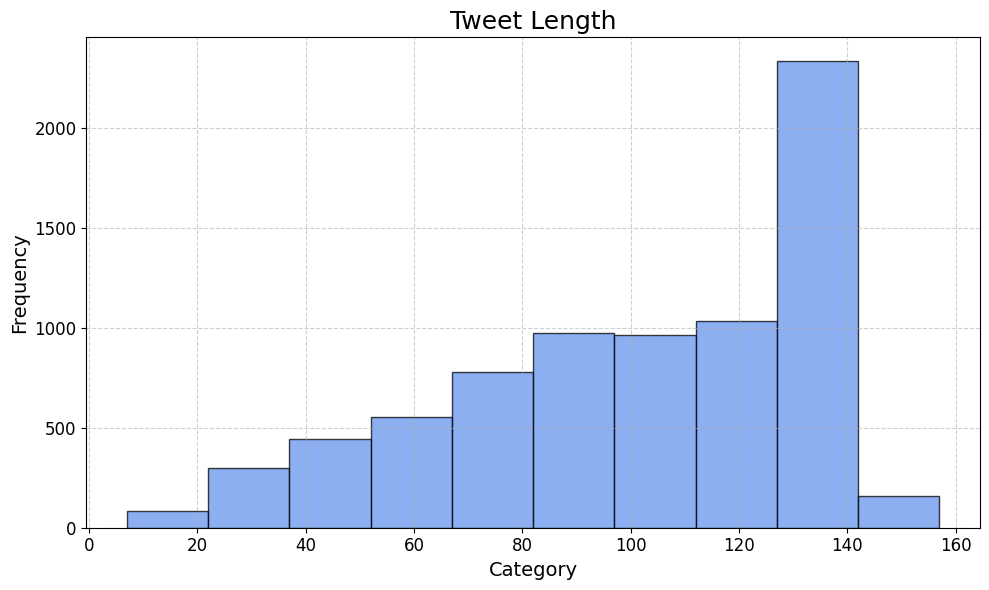

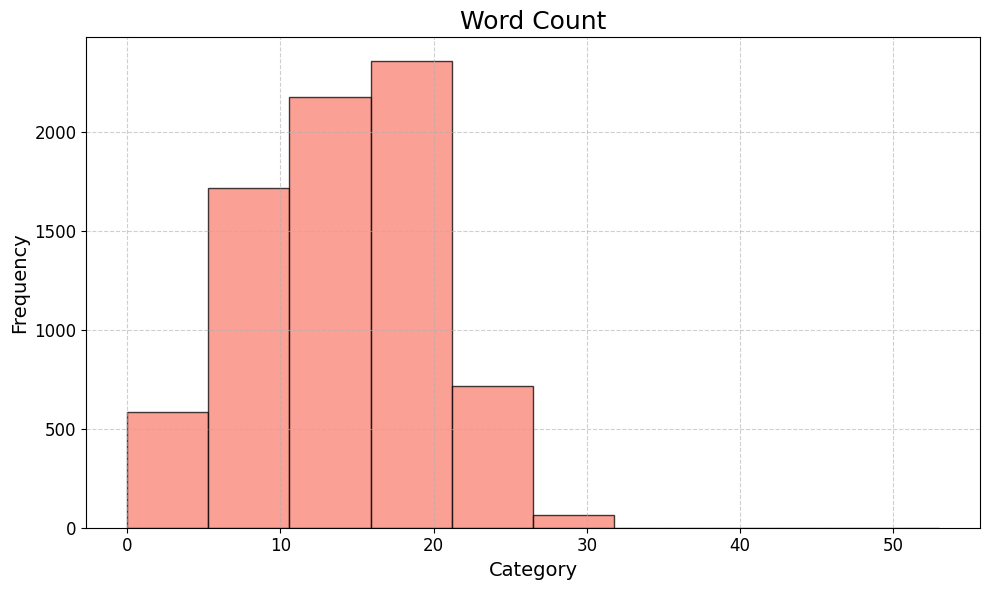

In [5]:
train['tweet_length'] = train['text'].str.len()
train['word_count'] = train['text'].str.count(' ')

train['keyword'] = train['keyword'].fillna(" ")

train['location'] = train['location'].fillna(" ")

print(train['keyword'].value_counts())
print(train['location'].value_counts())
print(train['target'].value_counts())

def plot_histogram(data, title, color):
    plt.figure(figsize=(10, 6))
    plt.hist(data, color=color, edgecolor='black', alpha=0.75)
    plt.title(title, fontsize=18)
    plt.xlabel("Category", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_histogram(train['tweet_length'], title="Tweet Length", color='cornflowerblue')
plot_histogram(train['word_count'], title="Word Count", color='salmon')

The Keyword column appears like it could be useful and maybe the tweet length also but the location field is too sparsely populated and many locations are in different formats etc.

The next step is to clean the text for easy comparison and then tokenization.

In [6]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text_list):
    cleaned = []
    for text in text_list:
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        text = re.sub(r'\d+', '', text)

        tokens = word_tokenize(text)
        tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

        cleaned_text = ' '.join(tokens)
        cleaned.append(cleaned_text)
    return cleaned

train['text']= clean_text(train['text'])

test['text']= clean_text(test['text'])

In [7]:
from collections import Counter


all_words = ' '.join(train['text']).split()
word_counts = Counter(all_words)


vocab_size = len(word_counts)
print(f"Unique words after cleaning: {vocab_size}")

Unique words after cleaning: 18683


For SVM projects the vectorization with TfidfVectorizer would have been the correct method to use here but when we care about word order tokenizer is better.

We have to pad the max number of words set to 32 such that each set of tokens is equal.

I will cap the number of words at 10000 and start with a 64 dimensional vector

My dense layer will return a binary variable which makes the sigmoid function applicable.

In [8]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train['text'])

X_train = tokenizer.texts_to_sequences(train['text'])
X_test = tokenizer.texts_to_sequences(test['text'])

maxlen = 32
X_train = pad_sequences(X_train, maxlen=maxlen, padding='post')
X_test = pad_sequences(X_test, maxlen=maxlen, padding='post')


### Model build and train

#### LSTM Neural Network

LSTM is a type of Recurrent Neural Network which addresses the vanishing gradient problem by applying a number of gates and a memory cell.

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])



In [10]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train,
    train['target'],
    test_size=0.2,  # 20% for validation
    random_state=42, # for reproducibility
    stratify=train['target'] # to maintain the proportion of target classes
)

Now some predictions

I have chosen an 80:20 validation split as I feel I have enough data

I will also start with a batch of 32

In [11]:


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', F1Score(average='weighted')])

early_stopping = EarlyStopping(
    monitor='f1_score',
    patience=2,
    mode='max',
    min_delta=0.001,
    restore_best_weights=True
)


history = model.fit(X_train_split, y_train_split, epochs=5, batch_size=32, validation_data=(X_val_split, y_val_split),
    callbacks=[early_stopping])

Epoch 1/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6159 - f1_score: 0.5977 - loss: 0.6515 - val_accuracy: 0.7814 - val_f1_score: 0.6008 - val_loss: 0.4806
Epoch 2/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8679 - f1_score: 0.6035 - loss: 0.3394 - val_accuracy: 0.8063 - val_f1_score: 0.6008 - val_loss: 0.4467
Epoch 3/5
191/191 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9355 - f1_score: 0.6014 - loss: 0.1904 - val_accuracy: 0.7899 - val_f1_score: 0.6008 - val_loss: 0.5619


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


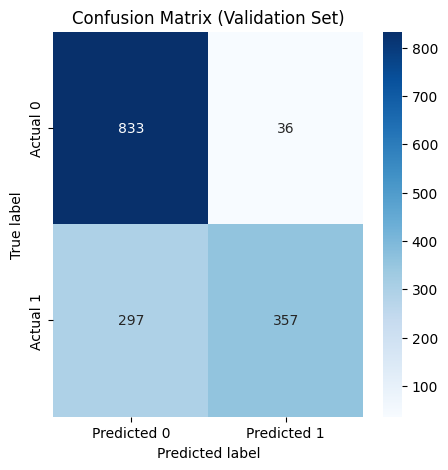

In [12]:
y_val_probs = model.predict(X_val_split)
y_val_pred = np.round(y_val_probs).astype(int).flatten()

cm = confusion_matrix(y_val_split, y_val_pred)

# Plot
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

In [13]:
predictions = model.predict(X_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [14]:
predictions = np.round(predictions).flatten()

submission = pd.DataFrame({
    "id": test['id'],
    "target": predictions.astype(int)
})

submission.to_csv("/content/drive/MyDrive/NLP_Disaster_Tweets/submission.csv", index=False)


After my first effort I decided to add more layers and dropout to attempt to reduce overfitting.

I have also reduced the size of the validation set to attempt in case 7600 tweets is too small a sample size.

In [15]:
X_train_split10, X_val_split10, y_train_split10, y_val_split10 = train_test_split(
    X_train,
    train['target'],
    test_size=0.1,
    random_state=42,
    stratify=train['target']
)

In [16]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.2),
    tf.keras.layers.LSTM(32, return_sequences=True, dropout=0.2),
    tf.keras.layers.LSTM(16, dropout=0.2), # return_sequences is False by default
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [17]:
model2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', F1Score(average='weighted')])

early_stopping = EarlyStopping(
    monitor='f1_score',
    patience=2,
    mode='max',
    min_delta=0.001,
    restore_best_weights=True
)

history2 = model2.fit(X_train_split10, y_train_split10, epochs=5, batch_size=32, validation_data=(X_val_split10, y_val_split10),
    callbacks=[early_stopping])

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.6158 - f1_score: 0.6011 - loss: 0.6449 - val_accuracy: 0.7940 - val_f1_score: 0.6006 - val_loss: 0.4703
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.8691 - f1_score: 0.6058 - loss: 0.3392 - val_accuracy: 0.8071 - val_f1_score: 0.6006 - val_loss: 0.4828
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9308 - f1_score: 0.5952 - loss: 0.2124 - val_accuracy: 0.7336 - val_f1_score: 0.6006 - val_loss: 0.6265


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


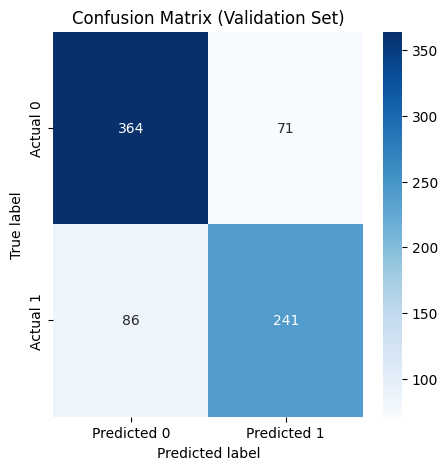

In [18]:
y_val_probs = model2.predict(X_val_split10)
y_val_pred = np.round(y_val_probs).astype(int).flatten()

cm = confusion_matrix(y_val_split10, y_val_pred)

# Plot
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

In [19]:
predictions2 = model2.predict(X_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [20]:
predictions2 = np.round(predictions2).flatten()

submission = pd.DataFrame({
    "id": test['id'],
    "target": predictions2.astype(int)
})

submission.to_csv("/content/drive/MyDrive/NLP_Disaster_Tweets/submission_2.csv", index=False)

## GRU

GRU processing is faster than LSTM and uses less computing power. LSTM is supposedly better for long complicated sequences of data. For this problem, all tweets are below 25 words so perhaps GRU will yield superior results.

I will further make the model simpler with a vectorize

In [21]:
model3 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

In [22]:
from keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0001)

model3.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='accuracy',
    patience=2,
    mode='max',
    min_delta=0.001,
    restore_best_weights=True
)

history3 = model3.fit(X_train_split10, y_train_split10, epochs=5, batch_size=32, validation_data=(X_val_split10, y_val_split10),
    callbacks=[early_stopping])

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.5491 - loss: 0.6892 - val_accuracy: 0.5709 - val_loss: 0.6832
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.5654 - loss: 0.6847 - val_accuracy: 0.5709 - val_loss: 0.6831
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5657 - loss: 0.6844 - val_accuracy: 0.5709 - val_loss: 0.6831
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5672 - loss: 0.6845 - val_accuracy: 0.5709 - val_loss: 0.6831


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


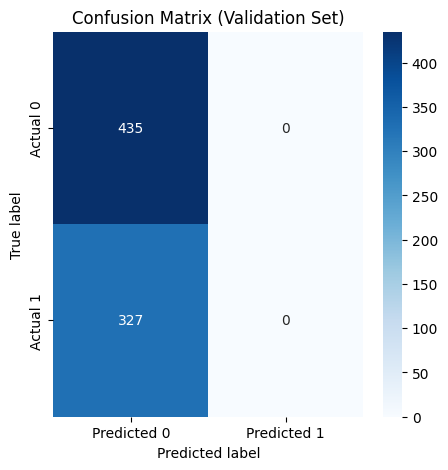

In [23]:
y_val_probs = model3.predict(X_val_split10)
y_val_pred = np.round(y_val_probs).astype(int).flatten()

cm = confusion_matrix(y_val_split10, y_val_pred)

# Plot
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

In [24]:
predictions3 = model3.predict(X_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [25]:
predictions3 = np.round(predictions3).flatten()

submission = pd.DataFrame({
    "id": test['id'],
    "target": predictions3.astype(int)
})

submission.to_csv("/content/drive/MyDrive/NLP_Disaster_Tweets/submission_3.csv", index=False)

## Results and conclusion

My first approach with LSTM was the most effective with a .76095 score, where the other approaches had around 0.74.

GRU processing as expected was much quicker than LSTM.

With Early Stopping, each of my models finished after 3 epochs - which may show signs of overfitting.

On reflection on the task itself, this is quite a complex thing for a simple language model to understand. Without the context of an image embedded in a tweet, many people may struggle to categorise the tweets. 7600 tweets of less than 32 words is also not a massive training set - which I would say may be required for sentiment analysis.